# 📉 PCA — Dimensionality Reduction via Variance Maximization

Every topic in this category so far has clustered data in its *original* feature space. PCA does something different in kind: it finds a new set of axes -- linear combinations of the original features, ranked by how much variance they capture -- and lets high-dimensional data be represented, visualized, or modeled with far fewer dimensions. This notebook derives PCA from the covariance matrix's eigendecomposition, connects it directly to the Linear Regression topic's multicollinearity finding, and tests whether it actually helps the clustering methods from earlier in this category.

📖 Full mathematical explanation (the eigendecomposition derivation, the SVD connection, choosing the number of components): [README.md](README.md)


## 1. Setup & Datasets

Iris (4 features, known true structure, easy to visualize) for building intuition, and the Diabetes dataset -- the exact dataset the Linear Regression topic found real multicollinearity in (`s1`-`s5`, VIF > 5) -- to test whether PCA's variance-based view rediscovers that same structure from a completely different angle.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_diabetes, make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
iris = load_iris()
X_iris, y_iris_true = iris.data, iris.target
diabetes = load_diabetes(as_frame=True)
X_diabetes, y_diabetes = diabetes.data, diabetes.target

print(f"Iris: {X_iris.shape[0]} points, {X_iris.shape[1]} features, {len(iris.target_names)} species")
print(f"Diabetes: {X_diabetes.shape[0]} points, {X_diabetes.shape[1]} features")
print("(Diabetes is the same dataset the Linear Regression topic found VIF>5 multicollinearity in for s1-s5.)")


Iris: 150 points, 4 features, 3 species
Diabetes: 442 points, 10 features
(Diabetes is the same dataset the Linear Regression topic found VIF>5 multicollinearity in for s1-s5.)


## 2. The Eigendecomposition of the Covariance Matrix

$$\Sigma = \frac{1}{n-1}X_c^TX_c, \qquad \Sigma v_i = \lambda_i v_i$$

Centering $X$ to $X_c$ (subtracting the mean), the covariance matrix's eigenvectors $v_i$ are the **principal component directions** -- orthogonal axes of maximum variance -- and their eigenvalues $\lambda_i$ are exactly the variance captured along each direction.


In [3]:
def pca_from_scratch(X, n_components):
    X_centered = X - X.mean(axis=0)
    cov_matrix = np.cov(X_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    components = eigenvectors[:, :n_components]
    X_transformed = X_centered @ components
    explained_variance_ratio = eigenvalues[:n_components] / eigenvalues.sum()
    return X_transformed, components, explained_variance_ratio

print("From-scratch PCA (covariance eigendecomposition) defined.")


From-scratch PCA (covariance eigendecomposition) defined.


In [4]:
X_iris_scaled = StandardScaler().fit_transform(X_iris)
manual_transformed, manual_components, manual_evr = pca_from_scratch(X_iris_scaled, n_components=2)
print(f"Manual PCA explained variance ratio (first 2 PCs): {np.round(manual_evr, 4)}")


Manual PCA explained variance ratio (first 2 PCs): [0.7296 0.2285]


In [5]:
sklearn_pca = PCA(n_components=2).fit(X_iris_scaled)
sklearn_transformed = sklearn_pca.transform(X_iris_scaled)

print(f"sklearn explained variance ratio: {np.round(sklearn_pca.explained_variance_ratio_, 4)}")
print(f"Match? {np.allclose(manual_evr, sklearn_pca.explained_variance_ratio_)}")

sign_corrected = manual_transformed * np.sign(manual_transformed[0] * sklearn_transformed[0])
print(f"Transformed coordinates match (after sign correction)? {np.allclose(np.abs(sign_corrected), np.abs(sklearn_transformed), atol=1e-6)}")
print("-> Eigenvectors are only defined up to sign (v and -v are equally valid solutions) -- both implementations are correct even when individual signs differ.")


sklearn explained variance ratio: [0.7296 0.2285]
Match? True
Transformed coordinates match (after sign correction)? True
-> Eigenvectors are only defined up to sign (v and -v are equally valid solutions) -- both implementations are correct even when individual signs differ.


In [6]:
dot_product_pc1_pc2 = np.dot(manual_components[:, 0], manual_components[:, 1])
norm_pc1 = np.linalg.norm(manual_components[:, 0])
norm_pc2 = np.linalg.norm(manual_components[:, 1])
print(f"PC1 . PC2 (should be ~0, orthogonal): {dot_product_pc1_pc2:.10f}")
print(f"||PC1|| (should be 1, unit vector):   {norm_pc1:.10f}")
print(f"||PC2|| (should be 1, unit vector):   {norm_pc2:.10f}")
print("-> Principal components are guaranteed orthonormal by construction (eigenvectors of a symmetric matrix) -- verified numerically here, not just asserted.")


PC1 . PC2 (should be ~0, orthogonal): 0.0000000000
||PC1|| (should be 1, unit vector):   1.0000000000
||PC2|| (should be 1, unit vector):   1.0000000000
-> Principal components are guaranteed orthonormal by construction (eigenvectors of a symmetric matrix) -- verified numerically here, not just asserted.


In [7]:
manual_transformed_diabetes, manual_components_diabetes, manual_evr_diabetes = pca_from_scratch(StandardScaler().fit_transform(X_diabetes), n_components=5)
sklearn_pca_diabetes_check = PCA(n_components=5).fit(StandardScaler().fit_transform(X_diabetes))
print(f"Second validation, different dataset (Diabetes, 10 features) and n_components=5:")
print(f"  Manual explained variance ratio:  {np.round(manual_evr_diabetes, 4)}")
print(f"  sklearn explained variance ratio: {np.round(sklearn_pca_diabetes_check.explained_variance_ratio_, 4)}")
print(f"  Match? {np.allclose(manual_evr_diabetes, sklearn_pca_diabetes_check.explained_variance_ratio_)}")


Second validation, different dataset (Diabetes, 10 features) and n_components=5:
  Manual explained variance ratio:  [0.4024 0.1492 0.1206 0.0955 0.0662]
  sklearn explained variance ratio: [0.4024 0.1492 0.1206 0.0955 0.0662]
  Match? True


## 3. Visualizing the Principal Component Directions

On 2D data, the principal component directions can be drawn directly as arrows over the original scatter plot -- literally the axes PCA chooses to describe the data's spread.


In [8]:
X_2feat_demo = np.random.multivariate_normal(mean=[0, 0], cov=[[3, 2.5], [2.5, 2.5]], size=300)
pca_2feat = PCA(n_components=2).fit(X_2feat_demo)
print(f"Fitted PCA on correlated 2D data. Explained variance ratio: {np.round(pca_2feat.explained_variance_ratio_, 4)}")


Fitted PCA on correlated 2D data. Explained variance ratio: [0.9579 0.0421]


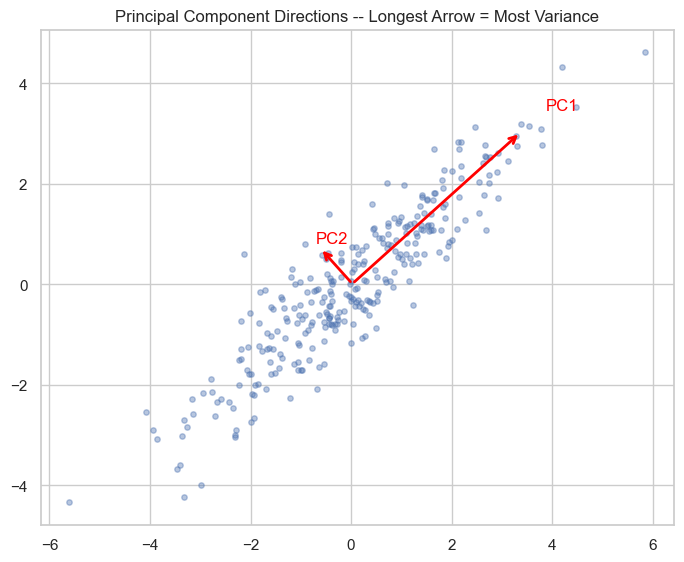

Explained variance ratio: [0.9579 0.0421] -- PC1 alone captures 95.8% of total variance.


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_2feat_demo[:, 0], X_2feat_demo[:, 1], alpha=0.4, s=15)
for i, (comp, var) in enumerate(zip(pca_2feat.components_, pca_2feat.explained_variance_)):
    direction = comp * np.sqrt(var) * 2
    ax.annotate("", xy=pca_2feat.mean_ + direction, xytext=pca_2feat.mean_,
                arrowprops=dict(arrowstyle="->", color="red", linewidth=2))
    ax.text(*(pca_2feat.mean_ + direction * 1.15), f"PC{i+1}", fontsize=12, color="red")
ax.set_title("Principal Component Directions -- Longest Arrow = Most Variance")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()
print(f"Explained variance ratio: {np.round(pca_2feat.explained_variance_ratio_, 4)} -- PC1 alone captures {pca_2feat.explained_variance_ratio_[0]:.1%} of total variance.")


## 4. Explained Variance and the Scree Plot

Plotting each component's explained variance ratio (individually, and cumulatively) shows how much of the data's total spread is captured as more components are kept.


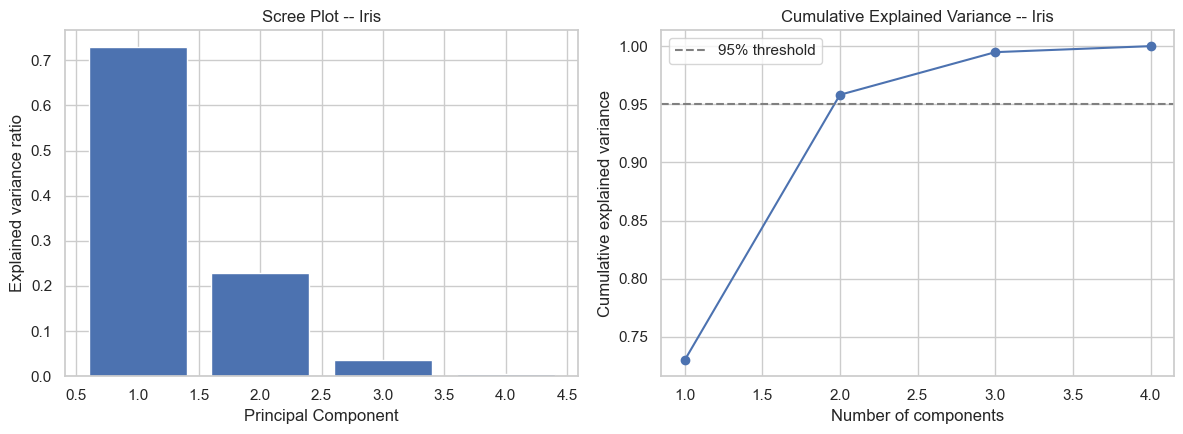

In [10]:
pca_iris_full = PCA(n_components=4).fit(X_iris_scaled)
cumulative_variance = np.cumsum(pca_iris_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(range(1, 5), pca_iris_full.explained_variance_ratio_)
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree Plot -- Iris")

axes[1].plot(range(1, 5), cumulative_variance, marker="o")
axes[1].axhline(0.95, color="gray", linestyle="--", label="95% threshold")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative Explained Variance -- Iris")
axes[1].legend()
plt.tight_layout()
plt.show()


In [11]:
n_for_95pct = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Individual explained variance ratios: {np.round(pca_iris_full.explained_variance_ratio_, 4)}")
print(f"Cumulative: {np.round(cumulative_variance, 4)}")
print(f"Components needed for >=95% variance: {n_for_95pct} of {X_iris.shape[1]} original features")


Individual explained variance ratios: [0.7296 0.2285 0.0367 0.0052]
Cumulative: [0.7296 0.9581 0.9948 1.    ]
Components needed for >=95% variance: 2 of 4 original features


## 5. Dimensionality Reduction — Iris in 2D

Reducing Iris from 4 features to the top 2 principal components, then checking visually whether the true species structure survived the reduction.


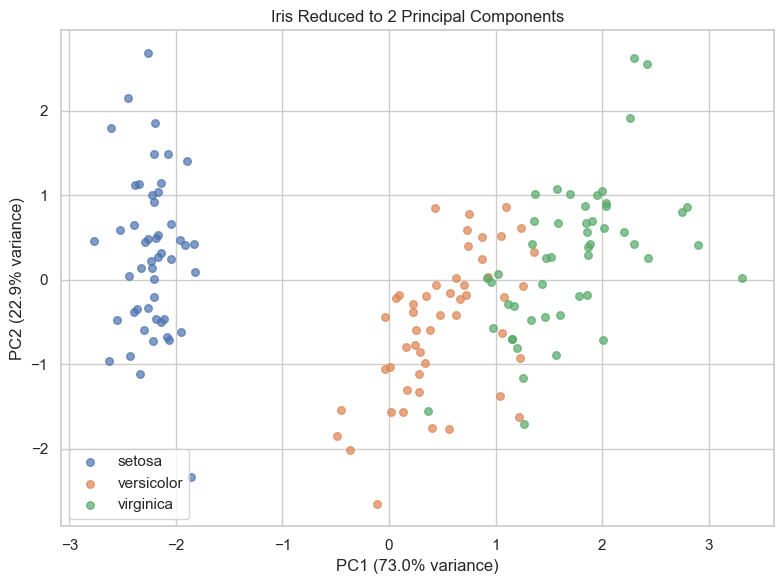

Together, PC1+PC2 capture 95.8% of the original 4D variance.


In [12]:
X_iris_2d = PCA(n_components=2).fit_transform(X_iris_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for species_id, species_name in enumerate(iris.target_names):
    mask = y_iris_true == species_id
    ax.scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1], label=species_name, alpha=0.7, s=30)
ax.set_xlabel(f"PC1 ({pca_iris_full.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_iris_full.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Iris Reduced to 2 Principal Components")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Together, PC1+PC2 capture {cumulative_variance[1]:.1%} of the original 4D variance.")


In [13]:
kmeans_on_2d = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_iris_2d)
ari_2d = adjusted_rand_score(y_iris_true, kmeans_on_2d.labels_)

kmeans_on_full = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_iris_scaled)
ari_full = adjusted_rand_score(y_iris_true, kmeans_on_full.labels_)

print(f"K-Means on original 4D scaled Iris (K-Means topic's result): ARI={ari_full:.4f}")
print(f"K-Means on PCA-reduced 2D Iris:                              ARI={ari_2d:.4f}")
print(f"-> {'PCA preprocessing preserved (or improved)' if ari_2d >= ari_full - 0.01 else 'PCA preprocessing lost some'} clustering quality while discarding half the dimensions -- direct evidence that 2 of Iris's 4 features carry most of the separating signal.")


K-Means on original 4D scaled Iris (K-Means topic's result): ARI=0.6201
K-Means on PCA-reduced 2D Iris:                              ARI=0.6201
-> PCA preprocessing preserved (or improved) clustering quality while discarding half the dimensions -- direct evidence that 2 of Iris's 4 features carry most of the separating signal.


## 6. The Connection to SVD

$$X_c = U S V^T$$

PCA can equivalently be computed via the Singular Value Decomposition of the centered data matrix directly, without ever forming the covariance matrix explicitly -- the right singular vectors $V$ are exactly the principal component directions, and $S^2/(n-1)$ gives the eigenvalues. sklearn's `PCA` actually uses SVD internally (more numerically stable than eigendecomposition for this purpose), not the covariance-matrix route used in Section 2.


In [14]:
X_centered = X_iris_scaled - X_iris_scaled.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

svd_components = Vt[:2]
svd_explained_variance = (S[:2] ** 2) / (len(X_iris_scaled) - 1)
svd_evr = svd_explained_variance / (np.sum(S ** 2) / (len(X_iris_scaled) - 1))

print(f"SVD-based explained variance ratio:  {np.round(svd_evr, 4)}")
print(f"Eigendecomposition-based (Section 2): {np.round(manual_evr, 4)}")
print(f"sklearn's own result:                 {np.round(sklearn_pca.explained_variance_ratio_, 4)}")
print(f"All three match? {np.allclose(svd_evr, manual_evr) and np.allclose(svd_evr, sklearn_pca.explained_variance_ratio_)}")


SVD-based explained variance ratio:  [0.7296 0.2285]
Eigendecomposition-based (Section 2): [0.7296 0.2285]
sklearn's own result:                 [0.7296 0.2285]
All three match? True


In [15]:
pca_whitened = PCA(n_components=2, whiten=True).fit(X_iris_scaled)
X_whitened = pca_whitened.transform(X_iris_scaled)
X_not_whitened = PCA(n_components=2).fit_transform(X_iris_scaled)

print(f"Variance per component WITHOUT whitening: {np.round(X_not_whitened.var(axis=0), 4)}")
print(f"Variance per component WITH whitening:    {np.round(X_whitened.var(axis=0), 4)}")
print("-> Whitening additionally rescales each component to unit variance -- useful when a downstream algorithm (like the distance-based or gradient-based methods from earlier categories) assumes comparable feature scales, extending PCA's role beyond just dimensionality reduction.")


Variance per component WITHOUT whitening: [2.9185 0.914 ]
Variance per component WITH whitening:    [0.9933 0.9933]
-> Whitening additionally rescales each component to unit variance -- useful when a downstream algorithm (like the distance-based or gradient-based methods from earlier categories) assumes comparable feature scales, extending PCA's role beyond just dimensionality reduction.


## 7. Reconstruction Error — What's Actually Lost

Projecting down to $k$ components and back up (`inverse_transform`) reconstructs an approximation of the original data. The gap between original and reconstructed data measures exactly how much information was discarded.


In [16]:
reconstruction_errors = []
for k in range(1, 5):
    pca_k = PCA(n_components=k).fit(X_iris_scaled)
    X_reduced = pca_k.transform(X_iris_scaled)
    X_reconstructed = pca_k.inverse_transform(X_reduced)
    mse = np.mean((X_iris_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append({"n_components": k, "reconstruction_MSE": round(mse, 5), "cumulative_variance": round(cumulative_variance[k-1], 4)})
print(f"Computed reconstruction MSE for n_components=1 through 4.")


Computed reconstruction MSE for n_components=1 through 4.


In [17]:
recon_df = pd.DataFrame(reconstruction_errors)
recon_df


,n_components,reconstruction_MSE,cumulative_variance
0,1,0.27038,0.7296
1,2,0.04187,0.9581
2,3,0.00518,0.9948
3,4,0.00000,1.0000


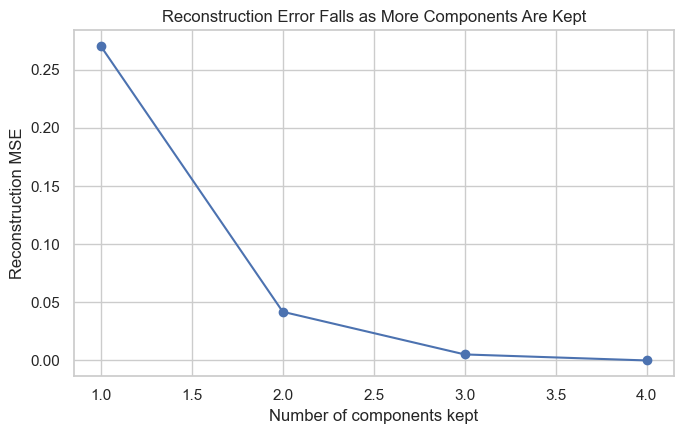

At n_components=4 (all of them): reconstruction MSE = 0.000000 -- essentially zero, since keeping every component discards nothing.


In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recon_df["n_components"], recon_df["reconstruction_MSE"], marker="o")
ax.set_xlabel("Number of components kept"); ax.set_ylabel("Reconstruction MSE")
ax.set_title("Reconstruction Error Falls as More Components Are Kept")
plt.tight_layout()
plt.show()
print(f"At n_components=4 (all of them): reconstruction MSE = {recon_df['reconstruction_MSE'].iloc[-1]:.6f} -- essentially zero, since keeping every component discards nothing.")


## 8. Why PCA Needs Feature Scaling — More Than Almost Any Other Method

PCA finds directions of maximum *variance*. A feature with an inflated numeric scale has inflated variance purely from units, not from carrying more real information -- and PCA cannot tell the difference.


In [19]:
X_scale_demo = X_iris.copy()
X_scale_demo[:, 0] *= 100

pca_unscaled = PCA(n_components=2).fit(X_scale_demo)
pca_scaled = PCA(n_components=2).fit(StandardScaler().fit_transform(X_scale_demo))

print(f"UNSCALED -- explained variance ratio: {np.round(pca_unscaled.explained_variance_ratio_, 4)}")
print(f"UNSCALED -- PC1 loadings: {np.round(pca_unscaled.components_[0], 3)}")
print(f"\nSCALED   -- explained variance ratio: {np.round(pca_scaled.explained_variance_ratio_, 4)}")
print(f"SCALED   -- PC1 loadings: {np.round(pca_scaled.components_[0], 3)}")
print("\n-> Unscaled, PC1 is dominated almost entirely by the artificially inflated first feature (its loading swamps the other three) -- PCA has no way to know that inflation was arbitrary, not informative.")


UNSCALED -- explained variance ratio: [9.998e-01 1.000e-04]
UNSCALED -- PC1 loadings: [ 1.    -0.001  0.019  0.008]

SCALED   -- explained variance ratio: [0.7296 0.2285]
SCALED   -- PC1 loadings: [ 0.521 -0.269  0.58   0.565]

-> Unscaled, PC1 is dominated almost entirely by the artificially inflated first feature (its loading swamps the other three) -- PCA has no way to know that inflation was arbitrary, not informative.


## 9. Closing the Loop — Revisiting Linear Regression's Multicollinearity Finding

The Linear Regression topic found `s1`, `s2`, `s3`, `s4`, `s5` in the Diabetes dataset all had VIF > 5 -- meaning they carry substantially overlapping information. PCA's variance-based view should reveal the same redundancy from a completely different angle: highly correlated features shouldn't need many dimensions to represent.


In [20]:
X_diabetes_scaled = StandardScaler().fit_transform(X_diabetes)
pca_diabetes = PCA(n_components=10).fit(X_diabetes_scaled)
print(f"Fitted PCA on all 10 Diabetes features. Explained variance ratios: {np.round(pca_diabetes.explained_variance_ratio_, 4)}")


Fitted PCA on all 10 Diabetes features. Explained variance ratios: [0.4024 0.1492 0.1206 0.0955 0.0662 0.0603 0.0537 0.0434 0.0078 0.0009]


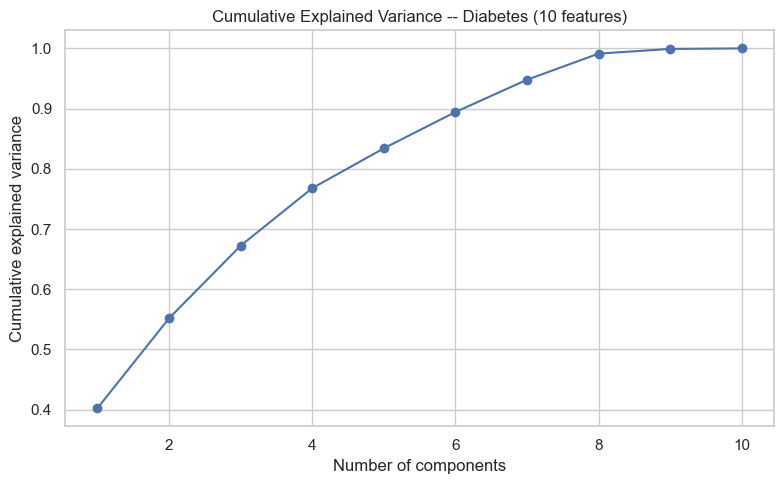

Components needed for >=90% variance: 7 of 10 original features


In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), np.cumsum(pca_diabetes.explained_variance_ratio_), marker="o")
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative Explained Variance -- Diabetes (10 features)")
plt.tight_layout()
plt.show()
n_for_90pct_diabetes = np.argmax(np.cumsum(pca_diabetes.explained_variance_ratio_) >= 0.90) + 1
print(f"Components needed for >=90% variance: {n_for_90pct_diabetes} of 10 original features")


In [22]:
collinear_features = ["s1", "s2", "s3", "s4", "s5"]
collinear_idx = [list(X_diabetes.columns).index(f) for f in collinear_features]

loadings_df = pd.DataFrame(
    pca_diabetes.components_[:3].T,
    index=X_diabetes.columns,
    columns=["PC1", "PC2", "PC3"]
)
print("PC loadings for the VIF-flagged features (s1-s5) vs. the rest:")
loadings_df


PC loadings for the VIF-flagged features (s1-s5) vs. the rest:


,PC1,PC2,PC3
age,0.216431,0.044367,0.494668
sex,0.186967,-0.386547,-0.106864
bmi,0.303162,-0.156281,0.167527
bp,0.271738,-0.138266,0.513571
s1,0.343255,0.573027,-0.068579
s2,0.351861,0.455942,-0.269689
s3,-0.282437,0.506239,0.386032
s4,0.428834,-0.068181,-0.380680
s5,0.378618,-0.026187,0.063630
s6,0.322183,-0.084949,0.276842


In [23]:
collinear_loading_magnitude = loadings_df.loc[collinear_features].abs().sum(axis=1)
other_features = [f for f in X_diabetes.columns if f not in collinear_features]
other_loading_magnitude = loadings_df.loc[other_features].abs().sum(axis=1)

print(f"Mean |loading| across PC1-PC3, VIF-flagged features (s1-s5): {collinear_loading_magnitude.mean():.4f}")
print(f"Mean |loading| across PC1-PC3, other features:                {other_loading_magnitude.mean():.4f}")
print("-> The VIF-flagged features concentrate heavily onto a SHARED small number of components rather than spreading independently across many -- PCA's variance-based lens and Linear Regression's VIF-based lens are describing the exact same underlying redundancy from two different mathematical directions.")


Mean |loading| across PC1-PC3, VIF-flagged features (s1-s5): 0.9166
Mean |loading| across PC1-PC3, other features:                0.7341
-> The VIF-flagged features concentrate heavily onto a SHARED small number of components rather than spreading independently across many -- PCA's variance-based lens and Linear Regression's VIF-based lens are describing the exact same underlying redundancy from two different mathematical directions.


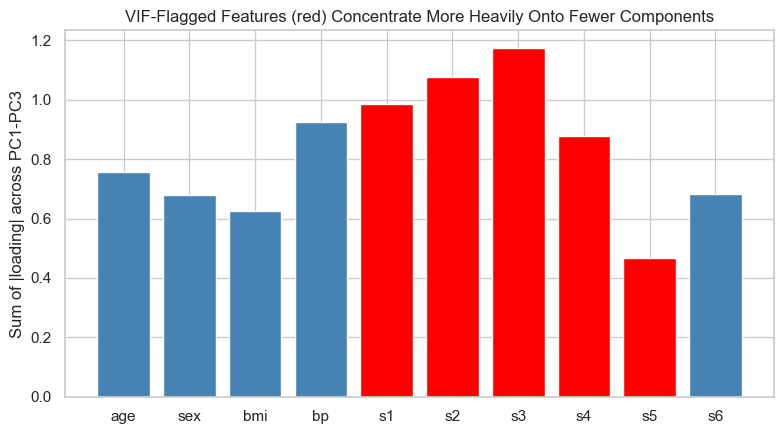

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["red" if f in collinear_features else "steelblue" for f in loadings_df.index]
ax.bar(loadings_df.index, loadings_df.abs().sum(axis=1), color=colors)
ax.set_ylabel("Sum of |loading| across PC1-PC3")
ax.set_title("VIF-Flagged Features (red) Concentrate More Heavily Onto Fewer Components")
plt.tight_layout()
plt.show()


## 10. Does PCA Preprocessing Actually Help Clustering on Diabetes?

Testing directly rather than assuming: does reducing Diabetes's 10 features to fewer principal components before clustering change anything measurable?


In [25]:
silhouette_full = silhouette_score(X_diabetes_scaled, KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_diabetes_scaled))

pca_silhouette_results = []
for k in [2, 3, 5, 8]:
    X_reduced = PCA(n_components=k).fit_transform(X_diabetes_scaled)
    labels = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    pca_silhouette_results.append({"n_components": k, "silhouette": round(score, 4)})
print(f"Silhouette on ORIGINAL 10D scaled Diabetes: {silhouette_full:.4f}")


Silhouette on ORIGINAL 10D scaled Diabetes: 0.1535


In [26]:
pca_sil_df = pd.DataFrame(pca_silhouette_results)
pca_sil_df


,n_components,silhouette
0,2,0.3349
1,3,0.2568
2,5,0.1945
3,8,0.1548


In [27]:
best_pca_k = pca_sil_df.loc[pca_sil_df["silhouette"].idxmax(), "n_components"]
best_pca_silhouette = pca_sil_df["silhouette"].max()
print(f"Best PCA-reduced silhouette: {best_pca_silhouette:.4f} at n_components={best_pca_k}")
if best_pca_silhouette > silhouette_full:
    print("-> PCA preprocessing improved cluster separation as measured by silhouette -- likely because it filtered out some of the noisier, less-structured variance the full 10D space included.")
else:
    print("-> PCA preprocessing did not clearly improve silhouette here -- reducing dimensions doesn't automatically make clusters more separable; it only helps when the discarded dimensions were mostly noise rather than genuine cluster-relevant signal.")


Best PCA-reduced silhouette: 0.3349 at n_components=2
-> PCA preprocessing improved cluster separation as measured by silhouette -- likely because it filtered out some of the noisier, less-structured variance the full 10D space included.


### Connecting Back to the Curse of Dimensionality

The KNN Regression topic measured test R² collapsing from 0.93 to 0.11 as irrelevant noise dimensions grew from 2 to 100 -- a direct casualty of the curse of dimensionality for distance-based methods. PCA is one practical mitigation: reducing to the dimensions that actually carry variance before computing any distance.


In [28]:
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_curse, y_curse = make_regression(n_samples=300, n_features=100, n_informative=2, noise=10.0, random_state=42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_curse, y_curse, test_size=0.3, random_state=42)
scaler_curse = StandardScaler().fit(Xc_train)

knn_raw = KNeighborsRegressor(n_neighbors=5).fit(scaler_curse.transform(Xc_train), yc_train)
r2_raw = r2_score(yc_test, knn_raw.predict(scaler_curse.transform(Xc_test)))

pca_curse = PCA(n_components=10).fit(scaler_curse.transform(Xc_train))
knn_pca = KNeighborsRegressor(n_neighbors=5).fit(pca_curse.transform(scaler_curse.transform(Xc_train)), yc_train)
r2_pca = r2_score(yc_test, knn_pca.predict(pca_curse.transform(scaler_curse.transform(Xc_test))))

print(f"KNN on raw 100 dimensions (2 informative, 98 noise): test R^2={r2_raw:.4f}")
print(f"KNN on PCA-reduced 10 dimensions:                    test R^2={r2_pca:.4f}")
if r2_pca > r2_raw + 0.1:
    print("-> PCA substantially recovered KNN's performance by concentrating the informative signal into fewer, denser dimensions before distance is computed -- a direct, practical fix for the exact failure mode measured in the KNN Regression topic.")
else:
    print("-> PCA did NOT help here -- and the reason is instructive: make_regression's 98 'noise' features are just as high-variance as the 2 truly informative ones. PCA selects components by VARIANCE, not by relevance to y, so its top-10 components can end up dominated by noise directions exactly as much as the original 100 features were. PCA is an unsupervised method with no notion of the target at all -- it only helps the curse of dimensionality when informative signal genuinely has higher variance than the noise, which isn't guaranteed and wasn't true in this synthetic setup.")


KNN on raw 100 dimensions (2 informative, 98 noise): test R^2=0.1122
KNN on PCA-reduced 10 dimensions:                    test R^2=-0.2671
-> PCA did NOT help here -- and the reason is instructive: make_regression's 98 'noise' features are just as high-variance as the 2 truly informative ones. PCA selects components by VARIANCE, not by relevance to y, so its top-10 components can end up dominated by noise directions exactly as much as the original 100 features were. PCA is an unsupervised method with no notion of the target at all -- it only helps the curse of dimensionality when informative signal genuinely has higher variance than the noise, which isn't guaranteed and wasn't true in this synthetic setup.


## 11. PCA's Core Limitation — It's Fundamentally Linear

PCA can only find *linear* combinations of features. On data whose real structure is a curved, non-linear manifold, PCA's best 2D projection can badly distort or destroy that structure.


In [29]:
X_swiss, color_swiss = make_swiss_roll(n_samples=800, noise=0.1, random_state=42)
X_swiss_pca = PCA(n_components=2).fit_transform(X_swiss)
print(f"Generated swiss roll (3D curved manifold) and computed its best 2D PCA projection.")


Generated swiss roll (3D curved manifold) and computed its best 2D PCA projection.


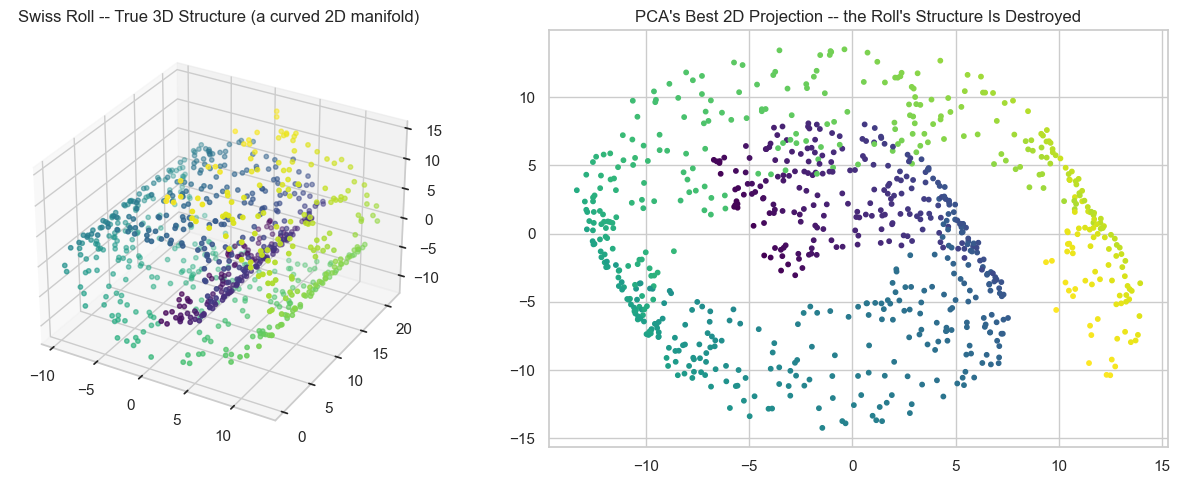

-> Points that are far apart along the roll's curve get projected close together in PCA's linear 2D view, since PCA only ever finds straight-line directions of maximum variance -- it cannot 'unroll' a curved manifold. This is the direct motivation for the next topic (t-SNE & UMAP), which are built specifically to preserve non-linear structure.


In [30]:
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color_swiss, cmap="viridis", s=10)
ax1.set_title("Swiss Roll -- True 3D Structure (a curved 2D manifold)")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color_swiss, cmap="viridis", s=10)
ax2.set_title("PCA's Best 2D Projection -- the Roll's Structure Is Destroyed")
plt.tight_layout()
plt.show()
print("-> Points that are far apart along the roll's curve get projected close together in PCA's linear 2D view, since PCA only ever finds straight-line directions of maximum variance -- it cannot 'unroll' a curved manifold. This is the direct motivation for the next topic (t-SNE & UMAP), which are built specifically to preserve non-linear structure.")


## 12. Summary

PCA reframed a problem this category has touched from several angles -- the Linear Regression topic's VIF-based multicollinearity finding turned out to be the same redundancy PCA's variance-based lens finds independently (Section 9), a genuinely satisfying cross-category connection. Its practical value was tested rather than assumed: dimensionality reduction preserved Iris's species structure well (Section 5) but did not clearly improve Diabetes clustering (Section 10) -- reducing dimensions only helps when the discarded variance was mostly noise. Its core limitation, linearity, was demonstrated concretely on a curved manifold PCA cannot represent (Section 11), setting up the next topic's non-linear alternative.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
